## 1. The problem

xxx some analysis

## 2.Load the data

In [3]:
import pandas as pd

df = pd.read_csv("sales.csv")
print("Dataset Done")

Dataset Done


In [9]:
display(df.head())

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


## 3 - Exploratory Data Analysis (EDA)

In [7]:
print(f"Shape: {df.shape}")
df.info()

Shape: (640840, 10)
<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB


In [10]:
print(df.columns)

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')


In [6]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [16]:
df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

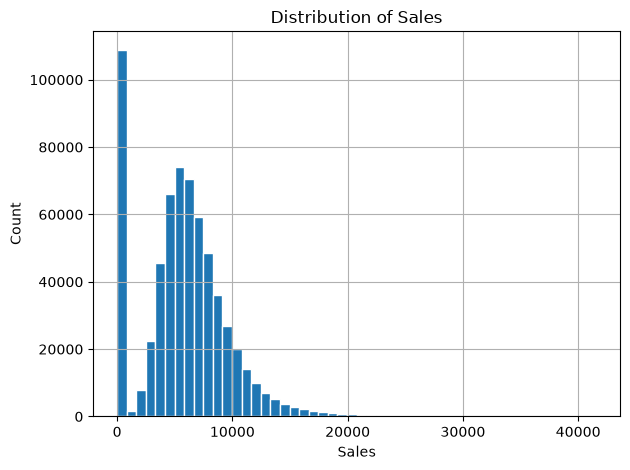

In [17]:
import matplotlib.pyplot as plt

df["sales"].hist(bins=50, edgecolor="white")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.title("Distribution of Sales")
plt.tight_layout()
plt.show()

In [19]:
df.sort_values("sales").head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
640812,49811,870,3,2014-07-23,0,0,0,0,1,0
573278,407993,261,7,2014-06-01,0,0,0,0,0,0
194399,668708,880,7,2014-03-16,0,0,0,0,0,0
546050,389639,472,2,2013-01-01,0,0,0,a,1,0
226300,79528,713,7,2014-08-03,0,0,0,0,0,0


In [29]:
df["sales"].value_counts()

sales
0        108855
5674        146
6049        134
5449        130
5723        128
          ...  
783           1
18891         1
27154         1
17964         1
16737         1
Name: count, Length: 20129, dtype: int64

In [31]:
df[df["sales"] == 0]

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
6,600327,659,7,2014-06-08,0,0,0,0,0,0
10,561067,273,7,2014-10-05,0,0,0,0,0,0
18,409022,767,7,2013-01-27,0,0,0,0,0,0
34,605423,534,7,2014-06-08,0,0,0,0,0,0
35,231682,514,7,2014-03-09,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
640807,381567,167,7,2014-07-27,0,0,0,0,0,0
640812,49811,870,3,2014-07-23,0,0,0,0,1,0
640814,556209,650,7,2014-03-23,0,0,0,0,0,0
640834,304137,329,7,2013-09-15,0,0,0,0,0,0


if the shop is not open, sales = 0
if the shop is open, we predict the value

In [35]:
df[df["open"] == 0]["sales"].sum()

np.int64(0)

In [21]:
df.sort_values("sales", ascending=False).head(10)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
288719,592337,909,1,2015-06-22,1721,1,0,0,0,41551
141722,260688,262,5,2015-04-03,5132,1,1,b,0,38722
324515,84682,262,5,2015-05-01,5458,1,1,a,0,38484
203893,251529,262,4,2015-05-14,5192,1,0,a,1,38367
263062,425213,57,1,2014-06-16,1970,1,1,0,0,38037
277137,111126,817,1,2013-12-16,4381,1,1,0,0,38025
494873,273625,262,4,2014-05-29,5297,1,0,a,0,37403
548053,344162,262,7,2013-12-22,4916,1,0,0,0,37376
410269,360569,262,7,2014-12-21,4962,1,0,0,0,37122
536475,37968,262,5,2013-03-29,5069,1,1,b,0,36227


### date issue

In [ ]:
# get the year, month "int" from date "str"


In [ ]:
# 3.3 sorting for data

### 3.8 - Identify correlations between features

In [45]:
# corr_df = df[[]]
# corr_df.corr()

## 4 - Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns='sales')
y = df['sales']

In [ ]:
# spiting data, use the 3.3 date soring, cosider time series
# train, validation, test  set

## 5 - Data Cleaning

In [ ]:
# 5.1 drop rows open==0 

# check state-holiday:  One-Hot-Encoding

## 6 - Establish a Baseline Model

In [46]:
# DummyRegression(),   dummy, always predict mean
# LinearRegression()

## 7 - Feature Engineering

In [47]:
# check state-holiday:  One-Hot-Encoding

## 8 - Feature Selection


## 9 - Handle Class Imbalance  ? maybe not

## 10 - Train and Compare Different Models

## 11 - Hyperparameter Tuning

## 12 - Final Evaluation on Test Set 

## 13 - Exporting our model (Pickle)